# Exploratory Data Analysis — UCI Credit Card Default

Dataset: [UCI Credit Card Default](https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

In [2]:
df = pd.read_csv("../data/raw/UCI_Credit_Card.csv.zip")
df.drop(columns=['ID'],inplace=True)

In [3]:
# handling data oddities
## The dataset contains undocumented values in EDUCATION (0, 5, 6) and MARRIAGE (0), 
# which do not match the documented categories.
df['EDUCATION'] = df['EDUCATION'].replace([0, 4, 5, 6], 4)
df['MARRIAGE'] = df['MARRIAGE'].replace(0, 3)



# The Missing PAY_1 Column
## The Oddity: The repayment status columns are named PAY_0, PAY_2, PAY_3, PAY_4, PAY_5, PAY_6.
##  There is no PAY_1. (PAY_0 represents September 2005, PAY_2 is August, etc.).
### also naming for ease
df.rename(columns={
    'PAY_0': 'PAY_SEP',
    'PAY_2': 'PAY_AUG',
    'PAY_3': 'PAY_JUL',
    'PAY_4': 'PAY_JUN',
    'PAY_5': 'PAY_MAY',
    'PAY_6': 'PAY_APR',
    
    'BILL_AMT1': 'BILL_SEP',
    'BILL_AMT2': 'BILL_AUG',
    'BILL_AMT3': 'BILL_JUL',
    'BILL_AMT4': 'BILL_JUN',
    'BILL_AMT5': 'BILL_MAY',
    'BILL_AMT6': 'BILL_APR',
    
    'PAY_AMT1': 'PAYMENT_SEP',
    'PAY_AMT2': 'PAYMENT_AUG',
    'PAY_AMT3': 'PAYMENT_JUL',
    'PAY_AMT4': 'PAYMENT_JUN',
    'PAY_AMT5': 'PAYMENT_MAY',
    'PAY_AMT6': 'PAYMENT_APR',
    
    'default.payment.next.month': 'DEFAULT_OCT'
}, inplace=True)

In [4]:
# Load data from /data/raw


df.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_SEP,PAY_AUG,PAY_JUL,PAY_JUN,PAY_MAY,...,BILL_JUN,BILL_MAY,BILL_APR,PAYMENT_SEP,PAYMENT_AUG,PAYMENT_JUL,PAYMENT_JUN,PAYMENT_MAY,PAYMENT_APR,DEFAULT_OCT
0,20000.0,2,2,1,24,2,2,-1,-1,-2,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,120000.0,2,2,2,26,-1,2,0,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,90000.0,2,2,2,34,0,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,50000.0,2,2,1,37,0,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,50000.0,1,2,1,57,-1,0,-1,0,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [5]:
df.shape

(30000, 24)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   LIMIT_BAL    30000 non-null  float64
 1   SEX          30000 non-null  int64  
 2   EDUCATION    30000 non-null  int64  
 3   MARRIAGE     30000 non-null  int64  
 4   AGE          30000 non-null  int64  
 5   PAY_SEP      30000 non-null  int64  
 6   PAY_AUG      30000 non-null  int64  
 7   PAY_JUL      30000 non-null  int64  
 8   PAY_JUN      30000 non-null  int64  
 9   PAY_MAY      30000 non-null  int64  
 10  PAY_APR      30000 non-null  int64  
 11  BILL_SEP     30000 non-null  float64
 12  BILL_AUG     30000 non-null  float64
 13  BILL_JUL     30000 non-null  float64
 14  BILL_JUN     30000 non-null  float64
 15  BILL_MAY     30000 non-null  float64
 16  BILL_APR     30000 non-null  float64
 17  PAYMENT_SEP  30000 non-null  float64
 18  PAYMENT_AUG  30000 non-null  float64
 19  PAYMENT_JUL  30

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
LIMIT_BAL,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
SEX,30000.0,1.603733,0.489129,1.0,1.00,2.0,2.00,2.0
EDUCATION,30000.0,1.842267,0.744494,1.0,1.00,2.0,2.00,4.0
MARRIAGE,30000.0,1.557267,0.521405,1.0,1.00,2.0,2.00,3.0
AGE,30000.0,35.485500,9.217904,21.0,28.00,34.0,41.00,79.0
PAY_SEP,30000.0,-0.016700,1.123802,-2.0,-1.00,0.0,0.00,8.0
PAY_AUG,30000.0,-0.133767,1.197186,-2.0,-1.00,0.0,0.00,8.0
PAY_JUL,30000.0,-0.166200,1.196868,-2.0,-1.00,0.0,0.00,8.0
PAY_JUN,30000.0,-0.220667,1.169139,-2.0,-1.00,0.0,0.00,8.0
PAY_MAY,30000.0,-0.266200,1.133187,-2.0,-1.00,0.0,0.00,8.0


In [8]:
# Check for missing values
df.isnull().sum()

LIMIT_BAL      0
SEX            0
EDUCATION      0
MARRIAGE       0
AGE            0
PAY_SEP        0
PAY_AUG        0
PAY_JUL        0
PAY_JUN        0
PAY_MAY        0
PAY_APR        0
BILL_SEP       0
BILL_AUG       0
BILL_JUL       0
BILL_JUN       0
BILL_MAY       0
BILL_APR       0
PAYMENT_SEP    0
PAYMENT_AUG    0
PAYMENT_JUL    0
PAYMENT_JUN    0
PAYMENT_MAY    0
PAYMENT_APR    0
DEFAULT_OCT    0
dtype: int64

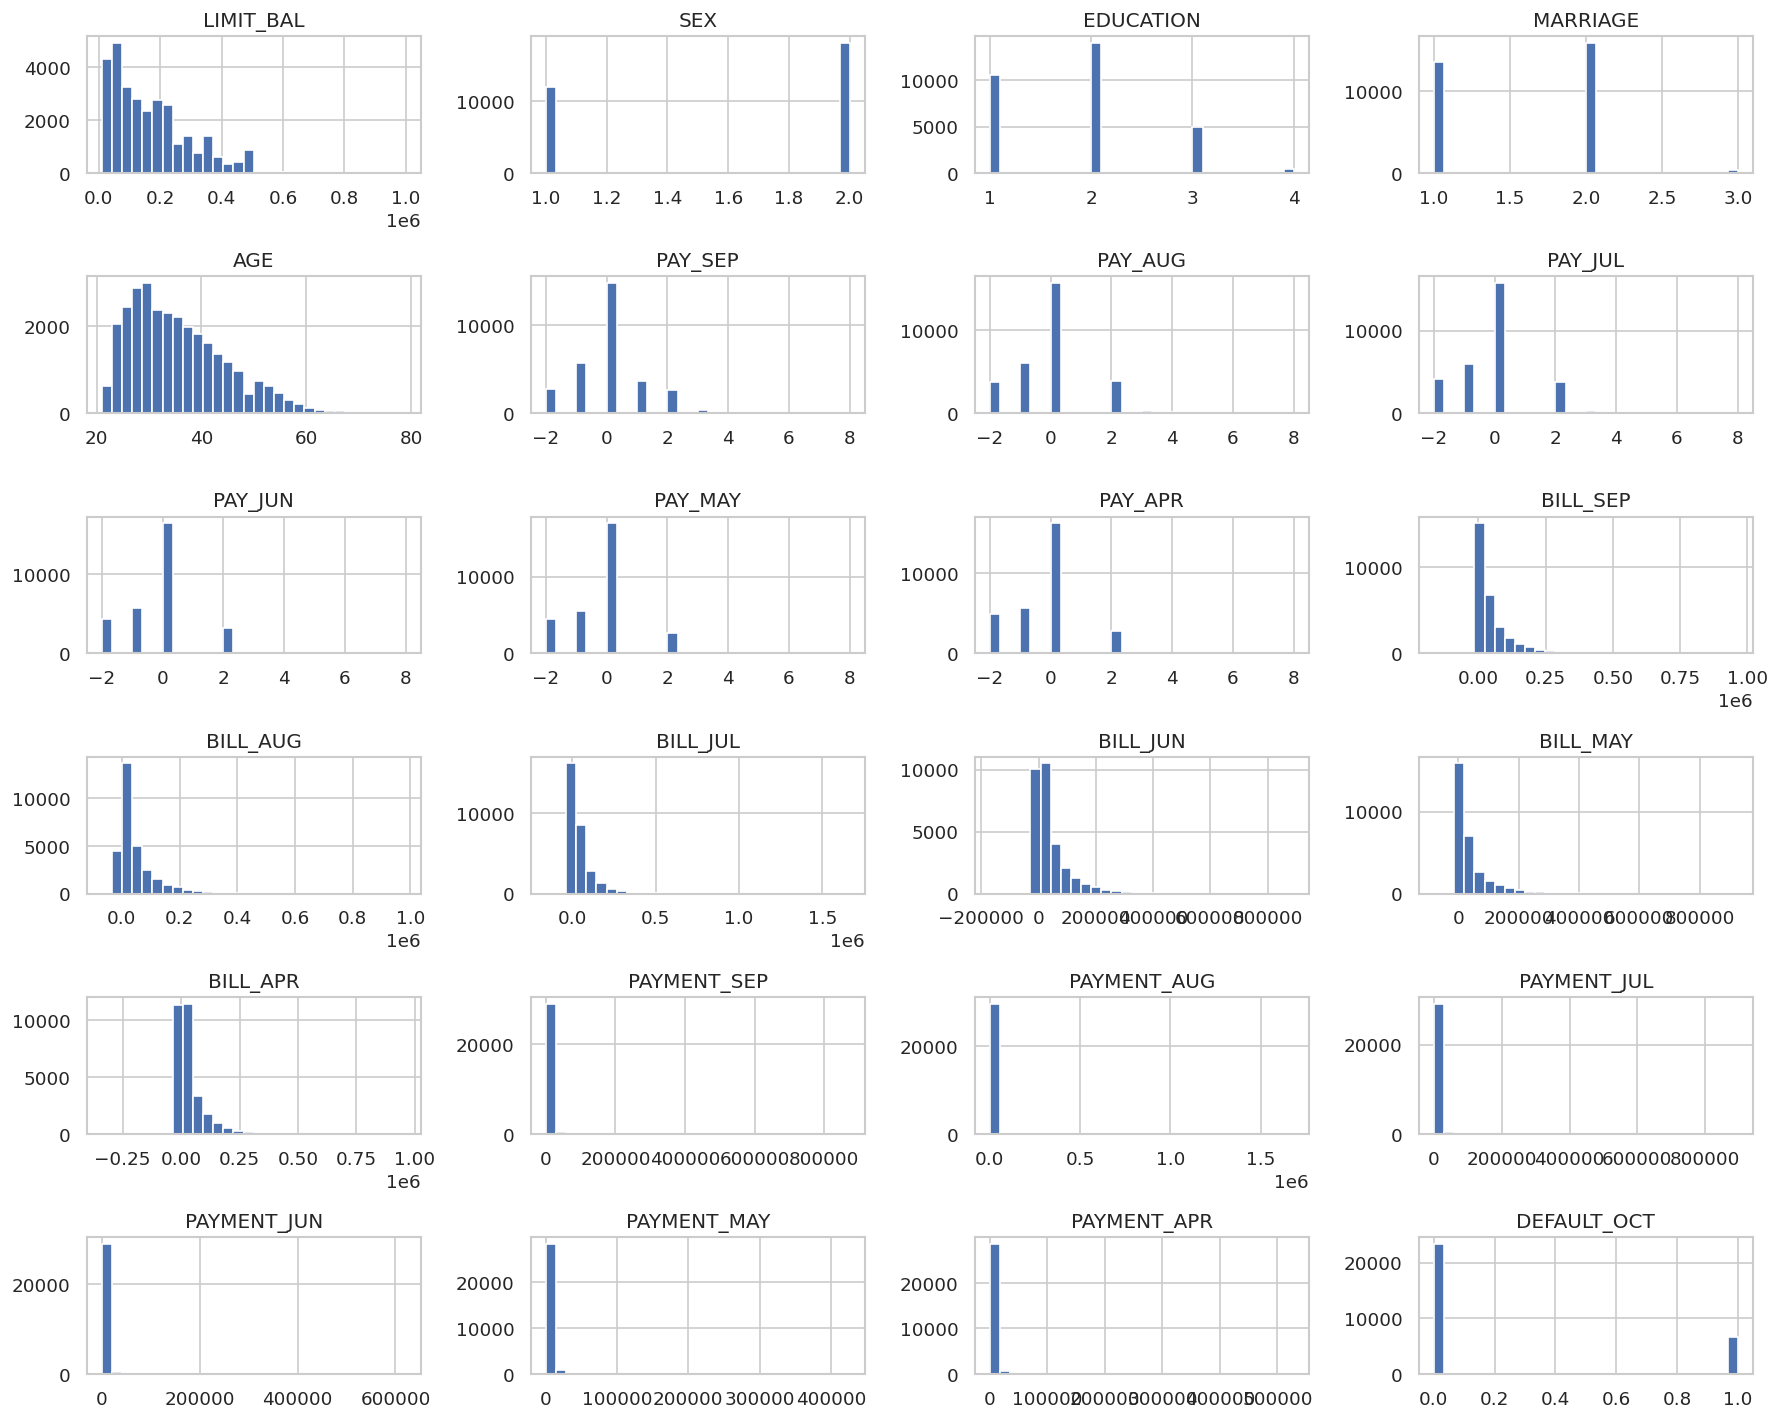

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot all numeric features (adjust columns as needed)
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

df[numeric_cols].hist(bins=30, figsize=(15, 12), layout=(6, 4))
plt.tight_layout()
plt.show()


In [10]:
# Target distribution
df["DEFAULT_OCT"].value_counts(normalize=True) # quick way to see if the class is imbalanced

DEFAULT_OCT
0    0.7788
1    0.2212
Name: proportion, dtype: float64

In [11]:
# check input features correlation with target
df.corr()['DEFAULT_OCT']

LIMIT_BAL     -0.153520
SEX           -0.039961
EDUCATION      0.033842
MARRIAGE      -0.027575
AGE            0.013890
PAY_SEP        0.324794
PAY_AUG        0.263551
PAY_JUL        0.235253
PAY_JUN        0.216614
PAY_MAY        0.204149
PAY_APR        0.186866
BILL_SEP      -0.019644
BILL_AUG      -0.014193
BILL_JUL      -0.014076
BILL_JUN      -0.010156
BILL_MAY      -0.006760
BILL_APR      -0.005372
PAYMENT_SEP   -0.072929
PAYMENT_AUG   -0.058579
PAYMENT_JUL   -0.056250
PAYMENT_JUN   -0.056827
PAYMENT_MAY   -0.055124
PAYMENT_APR   -0.053183
DEFAULT_OCT    1.000000
Name: DEFAULT_OCT, dtype: float64

/tmp/ipykernel_241998/2734299903.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr_target.values, y=corr_target.index, palette='coolwarm')


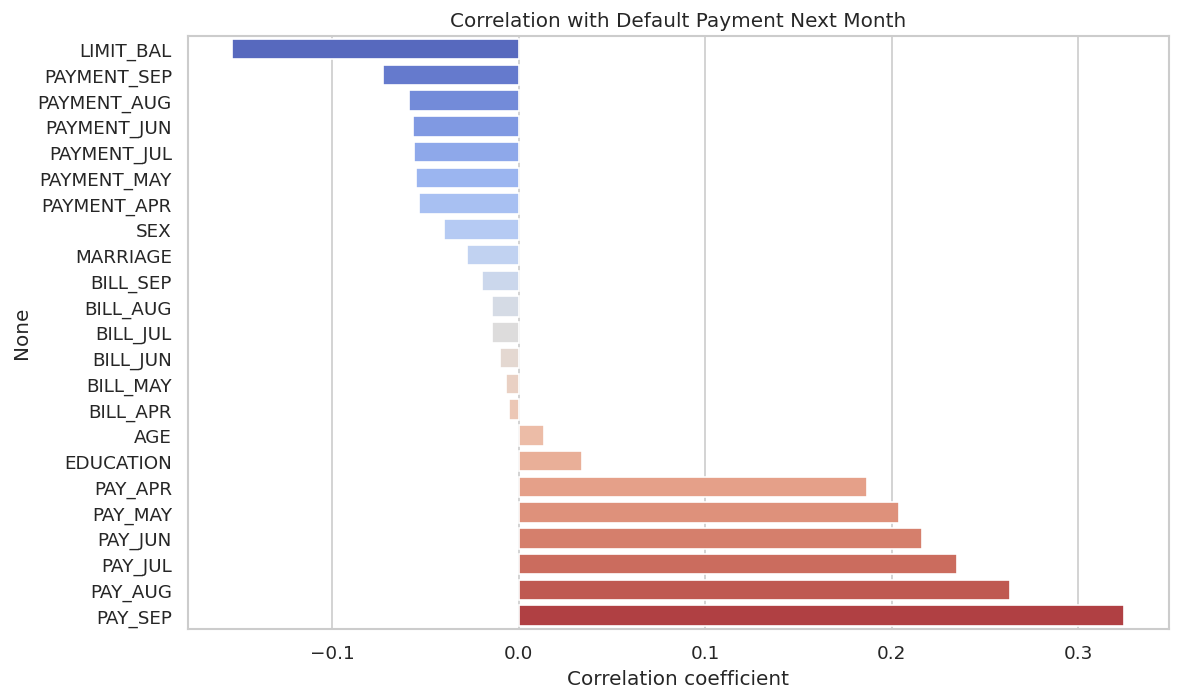

In [12]:
corr_target = df.corr()['DEFAULT_OCT'].drop('DEFAULT_OCT')

# Sort for better readability (optional)
corr_target = corr_target.sort_values()

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=corr_target.values, y=corr_target.index, palette='coolwarm')
plt.title('Correlation with Default Payment Next Month')
plt.xlabel('Correlation coefficient')
plt.tight_layout()
plt.show()

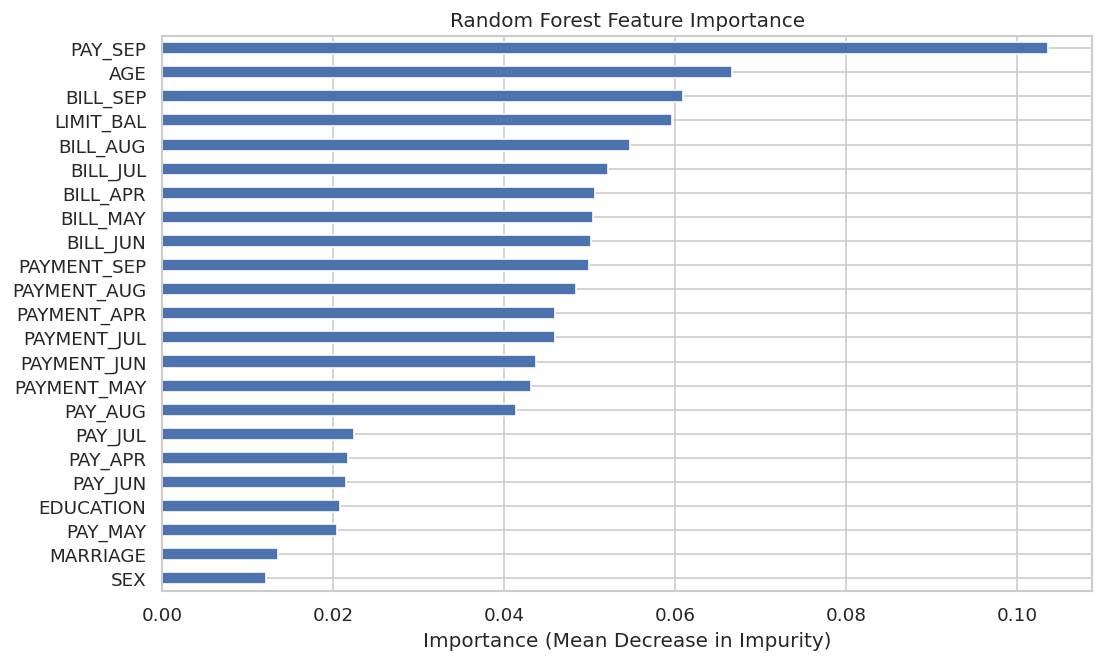

In [13]:
from sklearn.ensemble import RandomForestClassifier

# Separate features and target
X = df.drop('DEFAULT_OCT', axis=1)
y = df['DEFAULT_OCT']

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X, y)

# Get importance
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values()

# Plot
importances.plot(kind='barh', figsize=(10, 6))
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance (Mean Decrease in Impurity)')
plt.show()

#### con of Random forest:
##### Random Forest’s feature_importances_ or permutation importance) only tells you how much a feature affects the prediction — not whether higher values make default more or less likely.

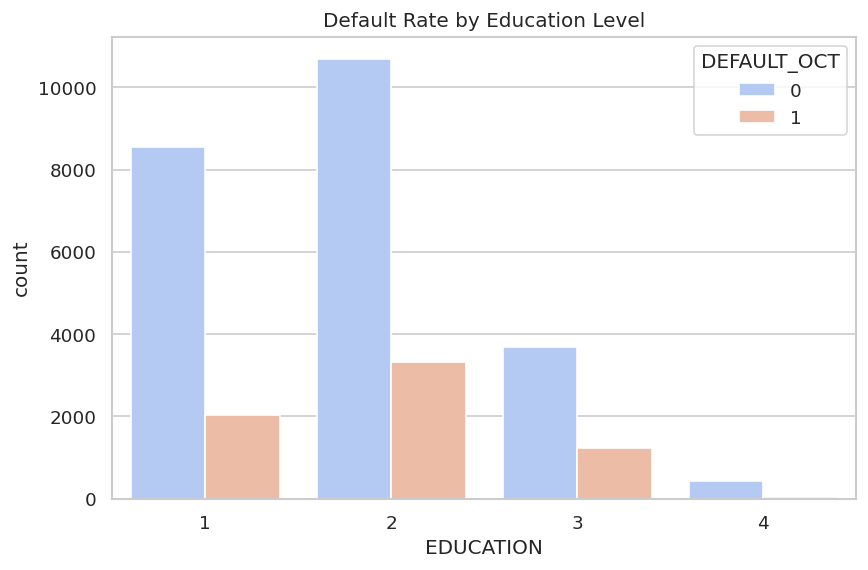

In [14]:
# drop gender and marriage as it often show surprisingly little predictive power, while 
# education has a slight trend
df.drop(columns=['SEX','MARRIAGE'],inplace=True)

# Visualize Education vs Default (since you kept it)
plt.figure(figsize=(8, 5))
sns.countplot(x='EDUCATION', hue='DEFAULT_OCT', data=df, palette='coolwarm')
plt.title('Default Rate by Education Level')
plt.show()

###### see that the ratio of defaulters (orange) to non-defaulters (blue) is roughly the same across all education levels (1, 2, 3, 4), visually proving it's not a strong predictor.

<Figure size 960x600 with 0 Axes>

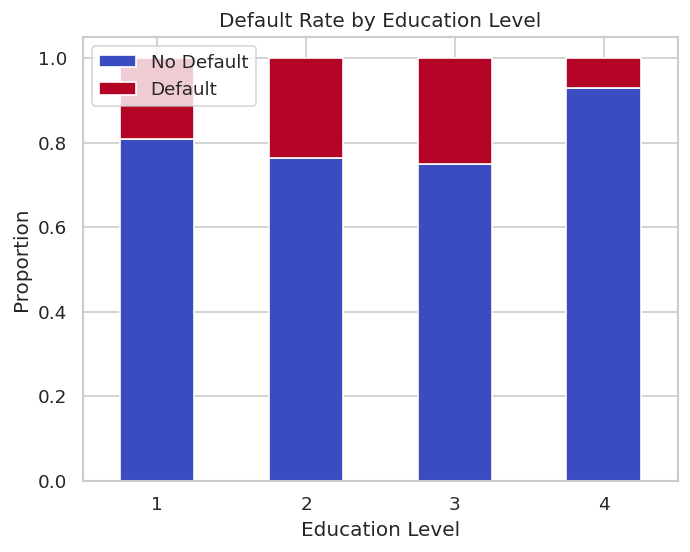

In [15]:
plt.figure(figsize=(8, 5))
# normalize='index' shows the percentage of defaults within each education level
pd.crosstab(df['EDUCATION'], df['DEFAULT_OCT'], normalize='index').plot(kind='bar', stacked=True, colormap='coolwarm')
plt.title('Default Rate by Education Level')
plt.ylabel('Proportion')
plt.xlabel('Education Level')
plt.xticks(rotation=0)
plt.legend(['No Default', 'Default'])
plt.show()

In [16]:
df.drop(columns=['EDUCATION'], inplace=True)

/tmp/ipykernel_241998/4090264732.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='DEFAULT_OCT', y='PAY_TREND', palette='coolwarm', ax=axes[1, 1])
/tmp/ipykernel_241998/4090264732.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1, 1].set_xticklabels(['Non-Defaulter', 'Defaulter'])
/tmp/ipykernel_241998/4090264732.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=default_rate.index, y=default_rate.values, palette='coolwarm', ax=axes[1, 2])


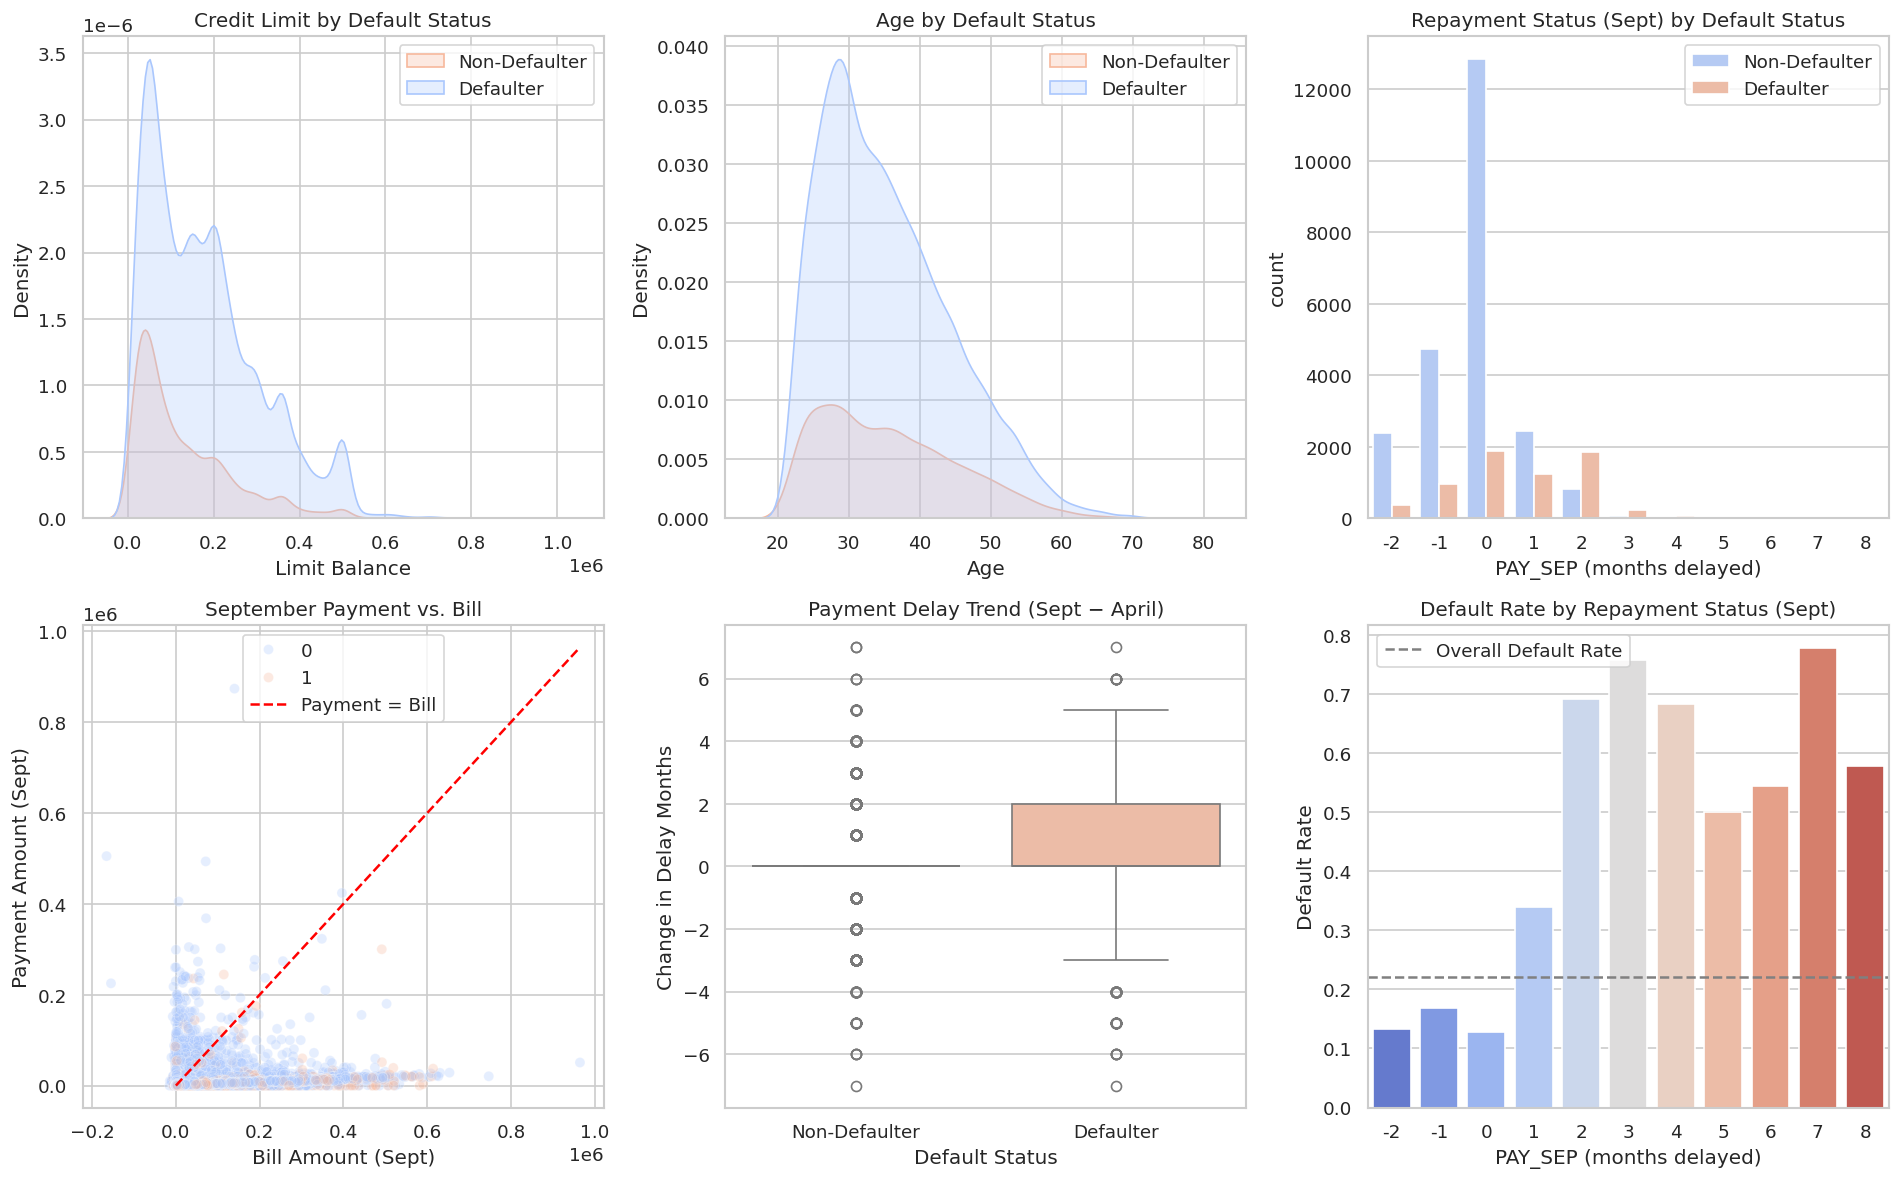

In [17]:
# =============================================================================
# Defaulters vs Non-Defaulters — 6-panel comparison
# =============================================================================
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# --- Panel 1: Credit Limit KDE ---
# Shows the distribution of LIMIT_BAL for each group. Defaulter curve is
# skewed left (lower credit limits) confirming the negative correlation with default.
sns.kdeplot(data=df, x='LIMIT_BAL', hue='DEFAULT_OCT', fill=True, alpha=0.3, palette='coolwarm', ax=axes[0, 0])
axes[0, 0].set_title('Credit Limit by Default Status')
axes[0, 0].set_xlabel('Limit Balance')
axes[0, 0].legend(['Non-Defaulter', 'Defaulter'])

# --- Panel 2: Age KDE ---
# Age distributions are nearly identical for both groups — age alone is a
# weak predictor, consistent with its near-zero correlation (~0.014).
sns.kdeplot(data=df, x='AGE', hue='DEFAULT_OCT', fill=True, alpha=0.3, palette='coolwarm', ax=axes[0, 1])
axes[0, 1].set_title('Age by Default Status')
axes[0, 1].set_xlabel('Age')
axes[0, 1].legend(['Non-Defaulter', 'Defaulter'])

# --- Panel 3: Repayment Status Countplot ---
# PAY_SEP is the strongest predictor. Defaulters cluster at PAY_SEP ≥ 1
# (delayed payment), while non-defaulters dominate PAY_SEP ≤ 0 (on-time or early).
sns.countplot(data=df, x='PAY_SEP', hue='DEFAULT_OCT', palette='coolwarm', ax=axes[0, 2])
axes[0, 2].set_title('Repayment Status (Sept) by Default Status')
axes[0, 2].set_xlabel('PAY_SEP (months delayed)')
axes[0, 2].legend(['Non-Defaulter', 'Defaulter'])

# --- Panel 4: Bill vs Payment Scatter ---
# Points below the red dashed line (payment < bill = underpaying) are
# overwhelmingly defaulters. Points above it (payment > bill = paying down debt)
# are mostly non-defaulters. This motivates a PAYMENT_RATIO feature.
sns.scatterplot(data=df, x='BILL_SEP', y='PAYMENT_SEP', hue='DEFAULT_OCT', alpha=0.3, palette='coolwarm', ax=axes[1, 0])
max_val = max(df['BILL_SEP'].max(), df['PAYMENT_SEP'].max())
axes[1, 0].plot([0, max_val], [0, max_val], color='red', linestyle='--', label='Payment = Bill')
axes[1, 0].set_title('September Payment vs. Bill')
axes[1, 0].set_xlabel('Bill Amount (Sept)')
axes[1, 0].set_ylabel('Payment Amount (Sept)')
axes[1, 0].legend()

# --- Panel 5: Payment Trend Boxplot ---
# PAY_TREND = PAY_SEP - PAY_APR (change in delay over 6 months).
df['PAY_TREND'] = df['PAY_SEP'] - df['PAY_APR']
# Defaulters show a positive median trend (worsening delays), while
# non-defaulters stay near 0 or negative (stable or improving).
sns.boxplot(data=df, x='DEFAULT_OCT', y='PAY_TREND', palette='coolwarm', ax=axes[1, 1])
axes[1, 1].set_title('Payment Delay Trend (Sept − April)')
axes[1, 1].set_xlabel('Default Status')
axes[1, 1].set_ylabel('Change in Delay Months')
axes[1, 1].set_xticklabels(['Non-Defaulter', 'Defaulter'])

# --- Panel 6: Default Rate by PAY_SEP ---
# Each bar is the proportion of defaulters at that PAY_SEP level. The grey
# dashed line is the overall default rate (~22%). PAY_SEP ≥ 2 has default rates
# far above baseline — this single feature alone is highly discriminative.
default_rate = df.groupby('PAY_SEP')['DEFAULT_OCT'].mean()
sns.barplot(x=default_rate.index, y=default_rate.values, palette='coolwarm', ax=axes[1, 2])
axes[1, 2].set_title('Default Rate by Repayment Status (Sept)')
axes[1, 2].set_xlabel('PAY_SEP (months delayed)')
axes[1, 2].set_ylabel('Default Rate')
axes[1, 2].axhline(y=df['DEFAULT_OCT'].mean(), color='gray', linestyle='--', label='Overall Default Rate')
axes[1, 2].legend()

plt.tight_layout()
plt.show()

###### 4th plot:  points below the red line (underpaying) are heavily dominated by the default class (orange/red), while points above the line (overpaying/paying off past debt) are mostly non-default. This perfectly justifies creating a PAYMENT_RATIO feature later.

###### 5th plot: see that people who default have a positive trend (their delay is getting worse over the 6 months), while non-defaulters stay at 0 or negative.


| Panel | Comment Summary |
|--------|----------------|
| **1 — Credit Limit KDE** | Defaulter curve is skewed left, indicating lower credit limits among defaulters. |
| **2 — Age KDE** | Distributions are nearly identical, suggesting age is a weak predictor of default. |
| **3 — PAY_SEP Countplot** | Defaulters cluster at payment delays ≥ 1, while non-defaulters are concentrated at ≤ 0. |
| **4 — Bill vs. Payment Scatter** | Underpayers are more likely to default, motivating the creation of a `PAYMENT_RATIO` feature. |
| **5 — PAY_TREND Boxplot** | Defaulters show worsening repayment behavior over six months, while non-defaulters remain relatively stable. |
| **6 — Default Rate by PAY_SEP** | Default rates for `PAY_SEP ≥ 2` are far above the baseline, making this feature highly discriminative. |

# Feature Engineering

In [18]:
# --- Drop AGE ---
# KDE plots showed near-identical distributions for both groups;
# correlation with DEFAULT_OCT is only 0.014.
df.drop(columns=['AGE'], inplace=True)

# --- TOTAL_DELAY_DAYS: cumulative delinquency burden across 6 months ---
# PAY_*: -2 = no credit, -1 = paid duly, 0 = revolving, 1+ = N months late.
# Only positive values are actual delays → clip at 0, sum, convert to days.
pay_cols = ['PAY_SEP', 'PAY_AUG', 'PAY_JUL', 'PAY_JUN', 'PAY_MAY', 'PAY_APR']
df['TOTAL_DELAY_DAYS'] = df[pay_cols].clip(lower=0).sum(axis=1) * 30

# --- Drop PAY_TREND ---
# PAY_TREND = PAY_SEP - PAY_APR is a linear combination of existing features — redundant.
df.drop(columns=['PAY_TREND'], inplace=True)

print(f"Shape after feature engineering: {df.shape}")
print(f"Features: {list(df.columns)}")
df.describe().T

Shape after feature engineering: (30000, 21)
Features: ['LIMIT_BAL', 'PAY_SEP', 'PAY_AUG', 'PAY_JUL', 'PAY_JUN', 'PAY_MAY', 'PAY_APR', 'BILL_SEP', 'BILL_AUG', 'BILL_JUL', 'BILL_JUN', 'BILL_MAY', 'BILL_APR', 'PAYMENT_SEP', 'PAYMENT_AUG', 'PAYMENT_JUL', 'PAYMENT_JUN', 'PAYMENT_MAY', 'PAYMENT_APR', 'DEFAULT_OCT', 'TOTAL_DELAY_DAYS']


,count,mean,std,min,25%,50%,75%,max
LIMIT_BAL,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
PAY_SEP,30000.0,-0.016700,1.123802,-2.0,-1.00,0.0,0.00,8.0
PAY_AUG,30000.0,-0.133767,1.197186,-2.0,-1.00,0.0,0.00,8.0
PAY_JUL,30000.0,-0.166200,1.196868,-2.0,-1.00,0.0,0.00,8.0
PAY_JUN,30000.0,-0.220667,1.169139,-2.0,-1.00,0.0,0.00,8.0
PAY_MAY,30000.0,-0.266200,1.133187,-2.0,-1.00,0.0,0.00,8.0
PAY_APR,30000.0,-0.291100,1.149988,-2.0,-1.00,0.0,0.00,8.0
BILL_SEP,30000.0,51223.330900,73635.860576,-165580.0,3558.75,22381.5,67091.00,964511.0
BILL_AUG,30000.0,49179.075167,71173.768783,-69777.0,2984.75,21200.0,64006.25,983931.0
BILL_JUL,30000.0,47013.154800,69349.387427,-157264.0,2666.25,20088.5,60164.75,1664089.0


In [19]:
# Should return 0 for all columns
print(df.isnull().sum().sum()) 
print(np.isinf(df).sum().sum())

0
0


# MLP-Ready Feature Cleanup

Dropping only redundant / MLP-hostile features, keeping what matters:

| Dropped | Why |
|---------|-----|
| `BILL_AUG` … `BILL_APR` (×5) | Highly autocorrelated with `BILL_SEP`. SEP is the most recent & predictive. |
| `PAYMENT_AUG` … `PAYMENT_APR` (×5) | Same — autocorrelated with `PAYMENT_SEP`. |
| `PAYMENT_RATIO_*` (×6) | Max ~300k outliers, near-zero corr (~0.01). MLP learns this from raw BILL_SEP + PAYMENT_SEP. |
| `RECENT_PAY_DELAY` | Exact duplicate of `PAY_SEP`. |
| `MAX_PAY_DELAY` | = max(PAY_*) — MLP learns max-pooling via ReLU. |
| `CONSECUTIVE_DELAYS` | Redundant with `TOTAL_DELAY_DAYS`. |

| Kept | Why |
|------|-----|
| `BILL_SEP` + `PAYMENT_SEP` | Raw dollar amounts so MLP can learn the **underpayment signal** (payment < bill → default) from the scatter-plot insight. |

**Final feature set: 10 columns** — the MLP gets repayment history (*when*), underpayment magnitude (*how much*), and cumulative burden.

In [20]:
# --- MLP Cleanup: drop redundant columns, keep what the MLP needs ---

# Drop older bill/payment months — highly autocorrelated with SEP.
# Keep BILL_SEP + PAYMENT_SEP so the MLP can learn the underpayment signal
# (payment < bill → default) that the scatter plot revealed.
old_months = ['AUG', 'JUL', 'JUN', 'MAY', 'APR']
old_bill = [f'BILL_{m}' for m in old_months]
old_pay  = [f'PAYMENT_{m}' for m in old_months]

# PAYMENT_RATIO_* — if they exist from earlier runs (extreme outliers)
ratio_cols = [f'PAYMENT_RATIO_{m}' for m in ['SEP', 'AUG', 'JUL', 'JUN', 'MAY', 'APR']]

# Hand-crafted features — redundant for an MLP
redundant = ['RECENT_PAY_DELAY', 'MAX_PAY_DELAY', 'CONSECUTIVE_DELAYS']

df.drop(columns=old_bill + old_pay + ratio_cols + redundant,
        inplace=True, errors='ignore')

print(f"Final shape: {df.shape}")
print(f"Features ({len(df.columns)-1}): {[c for c in df.columns if c != 'DEFAULT_OCT']}")
print(f"Target: DEFAULT_OCT")
df.describe().T

Final shape: (30000, 11)
Features (10): ['LIMIT_BAL', 'PAY_SEP', 'PAY_AUG', 'PAY_JUL', 'PAY_JUN', 'PAY_MAY', 'PAY_APR', 'BILL_SEP', 'PAYMENT_SEP', 'TOTAL_DELAY_DAYS']
Target: DEFAULT_OCT


,count,mean,std,min,25%,50%,75%,max
LIMIT_BAL,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.0,1000000.0
PAY_SEP,30000.0,-0.016700,1.123802,-2.0,-1.00,0.0,0.0,8.0
PAY_AUG,30000.0,-0.133767,1.197186,-2.0,-1.00,0.0,0.0,8.0
PAY_JUL,30000.0,-0.166200,1.196868,-2.0,-1.00,0.0,0.0,8.0
PAY_JUN,30000.0,-0.220667,1.169139,-2.0,-1.00,0.0,0.0,8.0
PAY_MAY,30000.0,-0.266200,1.133187,-2.0,-1.00,0.0,0.0,8.0
PAY_APR,30000.0,-0.291100,1.149988,-2.0,-1.00,0.0,0.0,8.0
BILL_SEP,30000.0,51223.330900,73635.860576,-165580.0,3558.75,22381.5,67091.0,964511.0
PAYMENT_SEP,30000.0,5663.580500,16563.280354,0.0,1000.00,2100.0,5006.0,873552.0
DEFAULT_OCT,30000.0,0.221200,0.415062,0.0,0.00,0.0,0.0,1.0


In [21]:
# =============================================================================
# Train / Val / Test Split + RobustScaler + Export
# =============================================================================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
import os
# --- 1. Stratified split: 70% train, 15% val, 15% test ---
# Stratification preserves the 22% default rate in each split.
X = df.drop(columns=['DEFAULT_OCT'])
y = df['DEFAULT_OCT']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

print(f"Train: {len(X_train):,}  |  Val: {len(X_val):,}  |  Test: {len(X_test):,}")
print(f"Train default rate: {y_train.mean():.3f}")
print(f"Val   default rate: {y_val.mean():.3f}")
print(f"Test  default rate: {y_test.mean():.3f}")

# --- 2. RobustScaler on continuous features with extreme outliers ---
# PAY_* columns (-2..8) are already well-scaled ordinals — no scaling needed.
scale_cols = ['LIMIT_BAL', 'BILL_SEP', 'PAYMENT_SEP', 'TOTAL_DELAY_DAYS']

scaler = RobustScaler()
X_train[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_val[scale_cols]   = scaler.transform(X_val[scale_cols])
X_test[scale_cols]  = scaler.transform(X_test[scale_cols])

# Reattach target for export
train = X_train.copy(); train['DEFAULT_OCT'] = y_train.values
val   = X_val.copy();   val['DEFAULT_OCT']   = y_val.values
test  = X_test.copy();  test['DEFAULT_OCT']  = y_test.values

# --- 3. Export ---
out_dir = "../data/processed"
os.makedirs(out_dir, exist_ok=True)

for name, data in [('train', train), ('val', val), ('test', test)]:
    path = f"{out_dir}/{name}.csv"
    data.to_csv(path, index=False)
    print(f"Exported {name}: {data.shape[0]:,} rows × {data.shape[1]} cols → {path}")

print(f"\nScaler used: RobustScaler (median/IQR) on {scale_cols}")
print(f"Scaler saved at: {out_dir}/scaler.pkl")

# Save the scaler for inference
import pickle
with open(f"{out_dir}/scaler.pkl", 'wb') as f:
    pickle.dump(scaler, f)

# Quick sanity check — scaled features stats
train[scale_cols].describe().T

Train: 21,000  |  Val: 4,500  |  Test: 4,500
Train default rate: 0.221
Val   default rate: 0.221
Test  default rate: 0.221
Exported train: 21,000 rows × 11 cols → ../data/processed/train.csv
Exported val: 4,500 rows × 11 cols → ../data/processed/val.csv
Exported test: 4,500 rows × 11 cols → ../data/processed/test.csv

Scaler used: RobustScaler (median/IQR) on ['LIMIT_BAL', 'BILL_SEP', 'PAYMENT_SEP', 'TOTAL_DELAY_DAYS']
Scaler saved at: ../data/processed/scaler.pkl


,count,mean,std,min,25%,50%,75%,max
LIMIT_BAL,21000.0,0.144732,0.682984,-0.684211,-0.473684,0.0,0.526316,4.526316
BILL_SEP,21000.0,0.455820,1.158623,-2.955100,-0.294490,0.0,0.705510,14.826767
PAYMENT_SEP,21000.0,0.879281,4.084543,-0.526826,-0.278147,0.0,0.721853,216.707118
TOTAL_DELAY_DAYS,21000.0,0.844095,1.785147,0.000000,0.000000,0.0,1.000000,18.000000


/tmp/ipykernel_241998/1165165279.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr_target.values, y=corr_target.index, palette='coolwarm', ax=ax1)


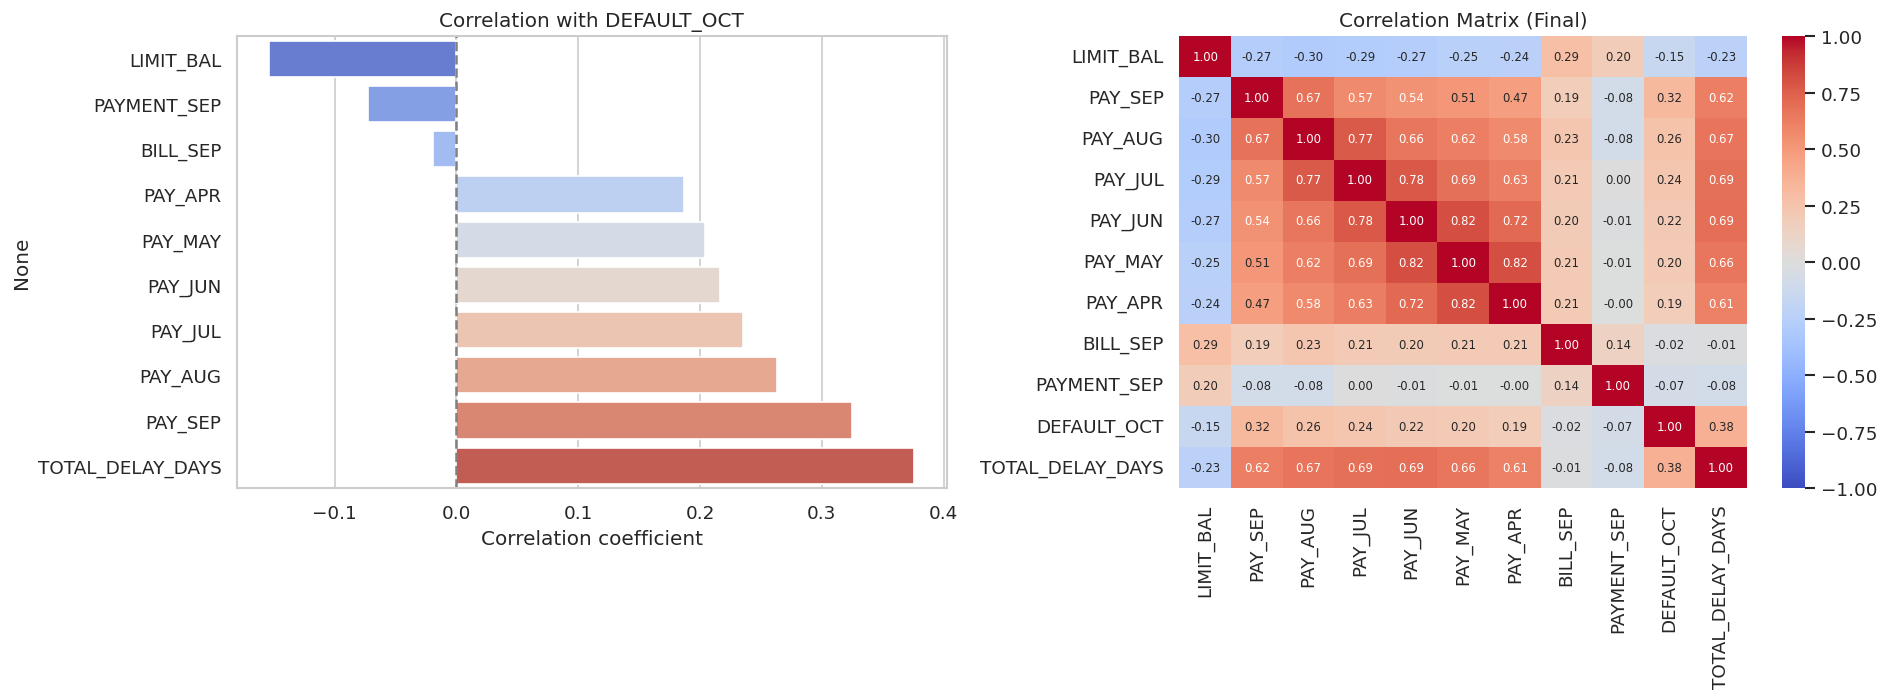

In [22]:
# Final correlation with target — clean, well-scaled features
corr_target = df.corr()['DEFAULT_OCT'].drop('DEFAULT_OCT').sort_values()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Barplot
sns.barplot(x=corr_target.values, y=corr_target.index, palette='coolwarm', ax=ax1)
ax1.set_title('Correlation with DEFAULT_OCT')
ax1.set_xlabel('Correlation coefficient')
ax1.axvline(x=0, color='gray', linestyle='--')

# Heatmap
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1, ax=ax2,
            annot_kws={'size': 7})
ax2.set_title('Correlation Matrix (Final)')

plt.tight_layout()
plt.show()